Purpose: Re-make BPPC/PPC2 profile plot to include all genotypes (break out by physiology), regardless of ZT-peak<br>
Author: Anna Pardo<br>
Date initiated: Jan. 7, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [3]:
# load time-structured gene information
cinfo = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/clusters_ngenes_gt_ztgroup_with36-61-43.txt",sep="\t",header="infer")
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0.0,319,53_1,5.0
1,2,53,1.0,656,53_2,21.0
2,3,53,1.0,882,53_3,17.0
3,4,53,0.0,1071,53_4,9.0
4,5,53,0.0,428,53_5,21.0


In [4]:
# load CAM gene annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")

In [5]:
# load TPM data
mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_935/3198679925.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [6]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [7]:
# subset by ZT (every 4 hours)
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]

In [8]:
def plottpm_genefamily(tpm,genefam,camdf=cam):
    camfam = camdf[camdf["gene_abbr"]==genefam]
    csgd = {}
    for i in range(len(camfam.index)):
        csgd[camfam.iloc[i,0]] = camfam.iloc[i,6]
    cgenes = [i for i in list(camfam["GeneID"].unique()) if i in tpm.columns]
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column
    plong["subgenome"] = plong["GeneID"].map(csgd)
    return plong.sort_values(by=["treat","subgenome"],ascending=False)

In [9]:
tpmbppc = plottpm_genefamily(zttpm,"BPPC")

In [10]:
tpmbppc.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
2613,SRR10663917,51,W,9.0,YufilH1044442m.g,9.934650,Yf
2646,SRR10848722,55,W,21.0,YufilH1044442m.g,1.096940,Yf
2645,SRR10848835,70,W,21.0,YufilH1044442m.g,40.981741,Yf
2644,SRR10848785,61,W,17.0,YufilH1044442m.g,0.938605,Yf
2643,SRR10848724,55,W,17.0,YufilH1044442m.g,1.569799,Yf


In [11]:
bppcdict = cam[cam["gene_abbr"]=="BPPC"][["GeneID","gene_abbr_unique"]].set_index("GeneID").to_dict()["gene_abbr_unique"]

In [12]:
bppcdict

{'Yucal.07G108300.v2.1': 'Ya_BPPC_1',
 'Yucal.07G108400.v2.1': 'Ya_BPPC_2',
 'Yucal.07G108500.v2.1': 'Ya_BPPC_3',
 'YufilH1044442m.g': 'Yf_BPPC'}

In [13]:
tpmbppc["genename"] = tpmbppc["GeneID"].map(bppcdict)
tpmbppc.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome,genename
2613,SRR10663917,51,W,9.0,YufilH1044442m.g,9.934650,Yf,Yf_BPPC
2646,SRR10848722,55,W,21.0,YufilH1044442m.g,1.096940,Yf,Yf_BPPC
2645,SRR10848835,70,W,21.0,YufilH1044442m.g,40.981741,Yf,Yf_BPPC
2644,SRR10848785,61,W,17.0,YufilH1044442m.g,0.938605,Yf,Yf_BPPC
2643,SRR10848724,55,W,17.0,YufilH1044442m.g,1.569799,Yf,Yf_BPPC


In [31]:
# reworked plot_profile() function - to plot profiles by subgenome as well as treatment
def plot_profile(fam,cpdf,axc,a,tf,titletext="Gene Family: ",log=False):
    # pull max TPM (out of curiosity)
    #maxtpm = int(round(max(cpdf["TPM"]),0))
    
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="subgenome")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="subgenome")
    
    #lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,1,where=t>=xthresh,color="gray",alpha=0.3,transform=a[axc].get_xaxis_transform())
    #a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=18)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=18)
    #a[axc].set_title(titletext+fam+" (max TPM: "+str(maxtpm)+")",fontsize=tf)
    a[axc].set_title(titletext+fam,fontsize=tf)

In [17]:
physcat = json.load(open("/home/leviathan22/Yucca_genomics/phys_figures/physiological_CAM_categories.json"))

In [18]:
tpmbppc["CAM physiology"] = tpmbppc["genotype"].map(physcat)
tpmbppc["CAM physiology"].unique()

array(['possible_fac_CAM', 'C3', 'facultative_CAM', nan], dtype=object)

In [19]:
tpmbppc["CAM physiology"].fillna(value="no data",inplace=True)

In [20]:
tpmbppc.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome,genename,CAM physiology
2613,SRR10663917,51,W,9.0,YufilH1044442m.g,9.934650,Yf,Yf_BPPC,possible_fac_CAM
2646,SRR10848722,55,W,21.0,YufilH1044442m.g,1.096940,Yf,Yf_BPPC,C3
2645,SRR10848835,70,W,21.0,YufilH1044442m.g,40.981741,Yf,Yf_BPPC,C3
2644,SRR10848785,61,W,17.0,YufilH1044442m.g,0.938605,Yf,Yf_BPPC,C3
2643,SRR10848724,55,W,17.0,YufilH1044442m.g,1.569799,Yf,Yf_BPPC,C3


In [21]:
c3 = tpmbppc[tpmbppc["CAM physiology"]=="C3"]
len(c3["genotype"].unique())

10

In [22]:
pfc = tpmbppc[tpmbppc["CAM physiology"]=="possible_fac_CAM"]
len(pfc["genotype"].unique())

7

In [23]:
fc = tpmbppc[tpmbppc["CAM physiology"]=="facultative_CAM"]
len(fc["genotype"].unique())

5

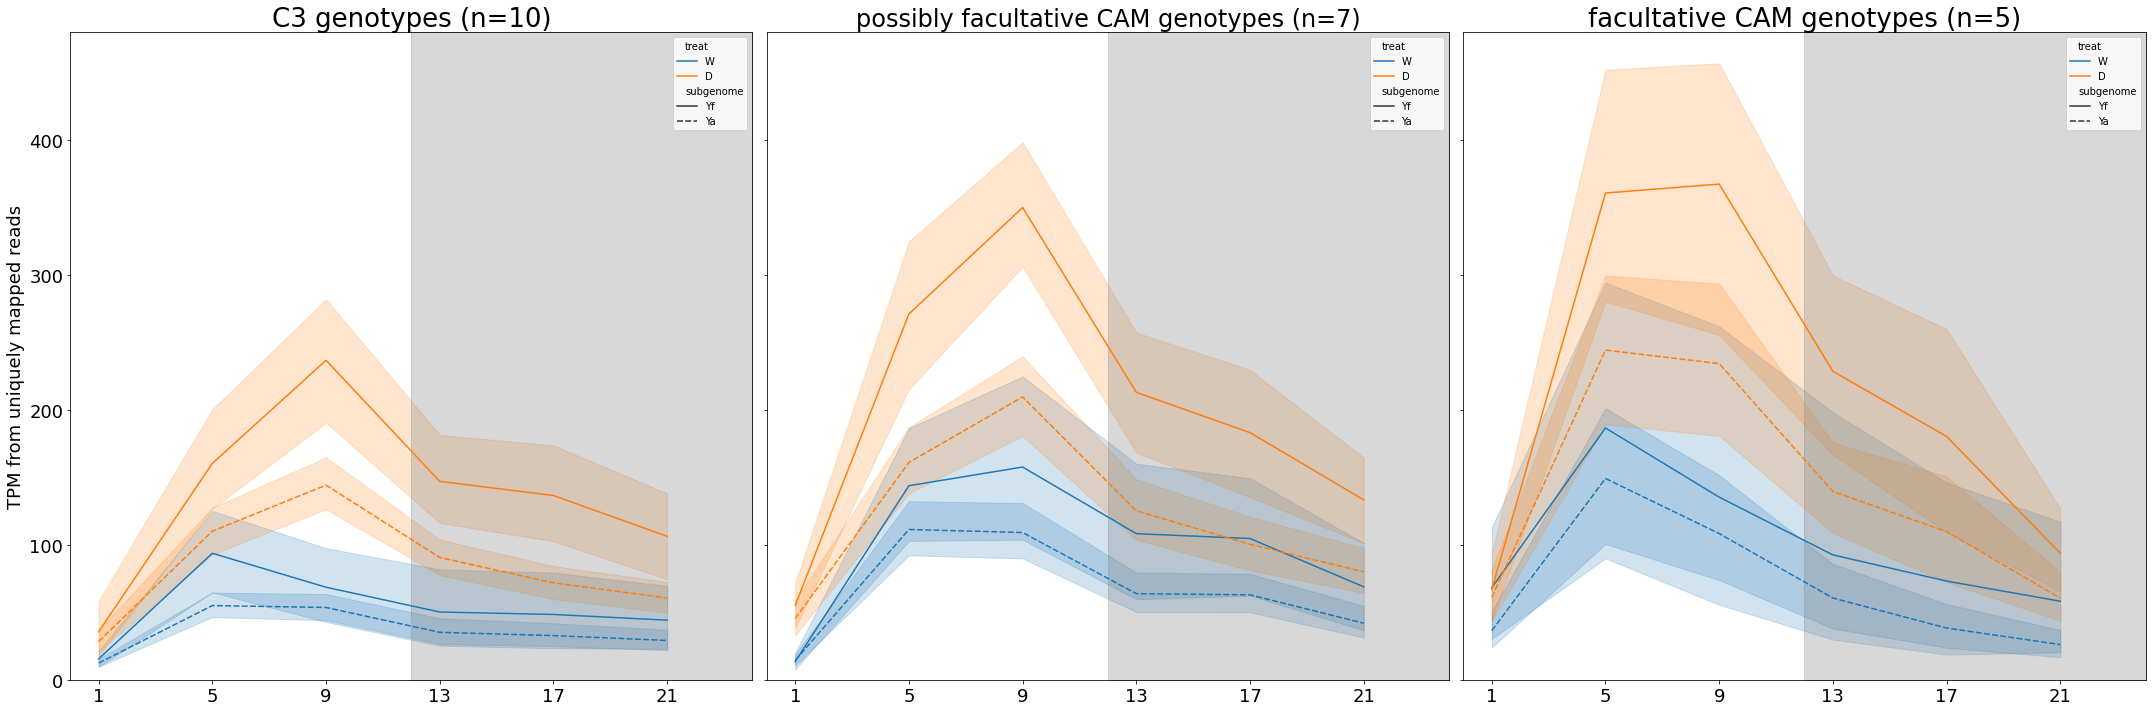

In [32]:
fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10),sharey=True)

#max_tpm = max(
#    c3["TPM"].max(),
#    pfc["TPM"].max(),
#    fc["TPM"].max()
#)

#for a in ax:
#    a.set_ylim(0, max_tpm * 0.52)

plot_profile("C3 genotypes (n=10)",c3,0,ax,26,"")
plot_profile("possibly facultative CAM genotypes (n=7)",pfc,1,ax,24,"")
plot_profile("facultative CAM genotypes (n=5)",fc,2,ax,26,"")
ylims = [a.get_ylim()[1] for a in ax]
ymax = max(ylims)
for a in ax:
    a.set_ylim(0, ymax)

fig.tight_layout()

plt.savefig("./allgt_bppc_profiles_byphys.png",dpi=200,bbox_inches="tight")
plt.savefig("./allgt_bppc_profiles_byphys.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./allgt_bppc_profiles_byphys.svg",dpi=200,bbox_inches="tight")

In [25]:
# right... do it again with each individual gene ID
# modify plot_profile() to plot lines for each individual gene
def plot_profile_gid(cpdf,axc,a,tf,titletext="Genotypes: ",log=False):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="genename",palette={"W":"tab:blue","D":"tab:orange"})
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="genename",palette={"W":"tab:blue","D":"tab:orange"})
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title(titletext,fontsize=tf)

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10))

max_tpm = max(
    c3["TPM"].max(),
    pfc["TPM"].max(),
    fc["TPM"].max()
)

for a in ax:
    a.set_ylim(0, max_tpm * 0.55)

plot_profile_gid(c3,0,ax,24,"C3 genotypes (n=10)")
plot_profile_gid(pfc,1,ax,22,"possibly facultative CAM genotypes (n=7)")
plot_profile_gid(fc,2,ax,24,"facultative CAM genotypes (n=5)")

plt.savefig("./allgt_bppc_gid_profiles_byphys.png",dpi=200,bbox_inches="tight")
plt.savefig("./allgt_bppc_gid_profiles_byphys.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./allgt_bppc_gid_profiles_byphys.svg",dpi=200,bbox_inches="tight")